# GluonTS API Tutorial: Probabilistic Time Series Forecasting

**Welcome!** This hands-on tutorial teaches you how to build probabilistic time series forecasts with [GluonTS](https://ts.gluon.ai/), an open-source Python library from AWS. You'll go from raw data to evaluated predictions — learning the *why* alongside the *how* at every step.

## Prerequisites

- Basic Python and pandas knowledge
- Familiarity with machine learning concepts (training, testing, epochs)
- No prior time series experience needed — we'll explain everything as we go

## What You'll Learn

1. How to prepare time series data for GluonTS (`ListDataset`)
2. How to configure, train, and evaluate three different forecasting models
3. When to pick each model for your problem
4. How to interpret **probabilistic** forecasts (confidence intervals, quantiles)

## The Three Models

| Model | Summary | Best for |
|-------|---------|----------|
| **DeepAR** | RNN that "remembers" past patterns | Complex seasonality, long-term dependencies |
| **SimpleFeedForward** | Direct mapping from recent history to future | Quick baselines, stable trends |
| **DeepNPTS** | Learns the data distribution without assumptions | Regime shifts, unusual distributions |

## Why Synthetic Data?

We start with synthetic time series instead of real-world data. This lets you focus on **how GluonTS works** without getting distracted by domain complexity (missing values, reporting artifacts, policy effects, etc.).

We'll progress through three levels of difficulty:

| Level | Pattern | What it tests |
|-------|---------|---------------|
| 1 | **Sinusoid** | Can the model learn a clean periodic signal? |
| 2 | **Multi-frequency** | Can it handle trend + seasonality + weekly cycles + noise? |
| 3 | **Regime change** | Can it adapt when the data's behavior changes midway? |

Once you're comfortable with the mechanics here, move to `GluonTS.example.ipynb` to see these models applied to real COVID-19 data.

---

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

from gluonts.torch.model.deepar import DeepAREstimator
from gluonts.torch.model.simple_feedforward import SimpleFeedForwardEstimator
from gluonts.torch.model.deep_npts import DeepNPTSEstimator
from gluonts.evaluation import make_evaluation_predictions

import utils_synthetic as synth
from utils_evaluation import calculate_metrics

print("All imports successful")

All imports successful


---

# Level 1: Sinusoid — The Simplest Pattern

We begin with a pure sine wave plus a small amount of Gaussian noise. This is the easiest pattern a model can encounter: perfectly periodic, no trend, no regime changes.

**Why start here?** If a model can't forecast a sinusoid, something is fundamentally wrong. This gives us a clean baseline to verify our pipeline works before increasing complexity.

## Generate and Visualize the Sinusoid

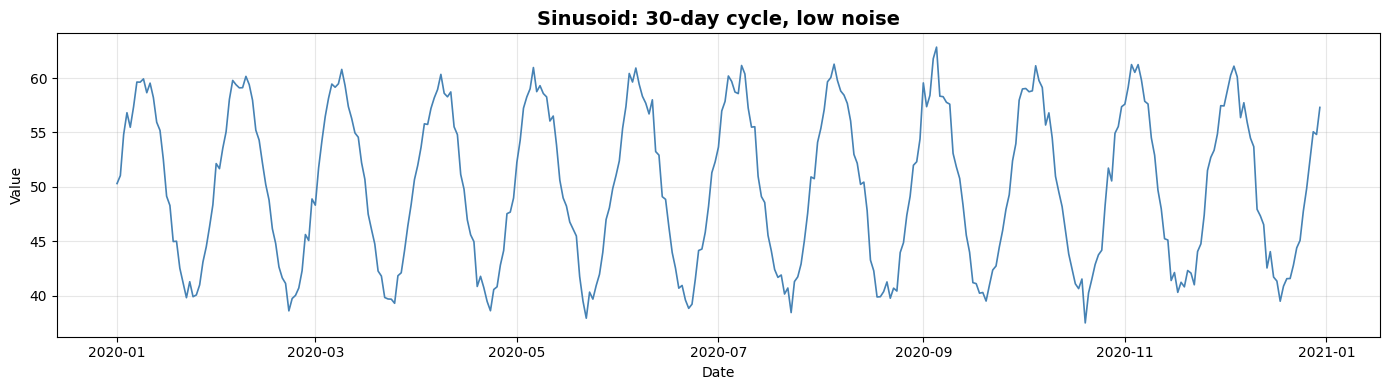

In [2]:
sin_df = synth.generate_sinusoid(
    n_points=365,
    period=30,
    amplitude=10.0,
    noise_std=1.0,
    seed=42,
)

synth.plot_synthetic_series(sin_df, title="Sinusoid: 30-day cycle, low noise")

## Prepare for GluonTS

GluonTS requires data in its `ListDataset` format. Each entry needs:
- `start` — the first timestamp
- `target` — a 1-D array of values
- `freq` — the time series frequency ("D" for daily)

Our `prepare_synthetic_dataset` function handles the train/test split and conversion. The last `prediction_length` days become the test set.

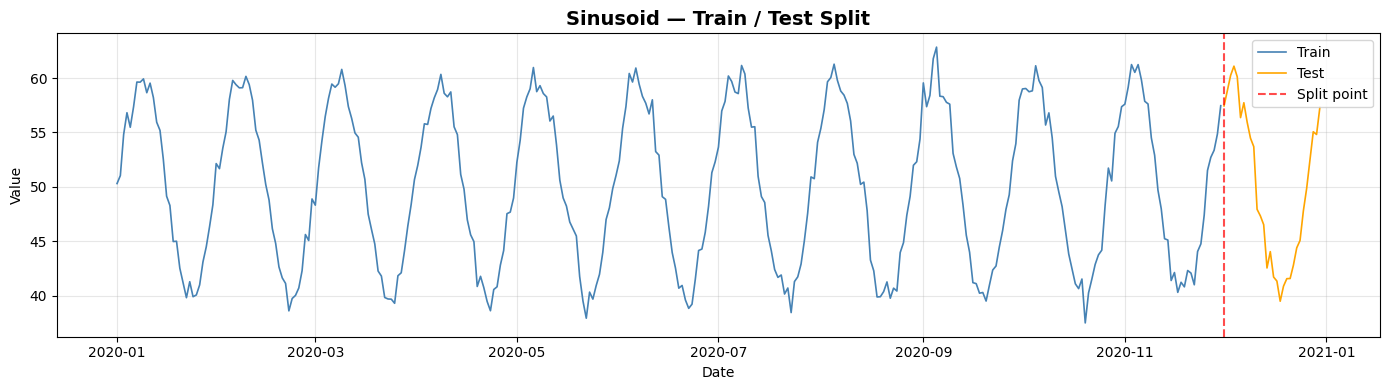

In [3]:
PREDICTION_LENGTH = 30

sin_data = synth.prepare_synthetic_dataset(
    sin_df,
    prediction_length=PREDICTION_LENGTH,
)

synth.plot_train_test_split(sin_data, title="Sinusoid — Train / Test Split")

## DeepAR on the Sinusoid

**Analogy:** Think of DeepAR like reading a book — it processes the story *sequentially*, remembering earlier chapters (context) to predict what comes next.

Under the hood, DeepAR is a recurrent neural network (RNN) that outputs a *probability distribution* at each time step, not a single point.

### Configuration

| Parameter | Value | Why |
|-----------|-------|-----|
| `prediction_length` | 30 | Forecast 30 days ahead |
| `context_length` | 60 | Look at 2 months of history |
| `num_layers` | 2 | Depth of the RNN |
| `hidden_size` | 40 | Neurons per layer |
| `freq` | "D" | Daily data |
| `epochs` | 5 | Enough for a simple pattern |

In [4]:
deepar_estimator = DeepAREstimator(
    prediction_length=PREDICTION_LENGTH,
    context_length=60,
    freq="D",
    num_layers=2,
    hidden_size=40,
    trainer_kwargs={"max_epochs": 5},
)

### Train DeepAR

Calling `.train()` runs the full training loop (powered by PyTorch Lightning).

In [5]:
deepar_predictor = deepar_estimator.train(sin_data["train_ds"])
print("DeepAR training complete")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs

  | Name  | Type        | Params | In sizes                                                         | Out sizes   
------------------------------------------------------------------------------------------------------------------------
0 | model | DeepARModel | 25.9 K | [[1, 1], [1, 1], [1, 1152, 4], [1, 1152], [1, 1152], [1, 30, 4]] | [1, 100, 30]
------------------------------------------------------------------------------------------------------------------------
25.9 K    Trainable params
0         Non-trainable params
25.9 K    Total params
0.104     Total estimated model params size (MB)


Epoch 0: |                                       | 50/? [00:00<00:00, 53.58it/s, v_num=4, train_loss=4.040]

Epoch 0, global step 50: 'train_loss' reached 4.04017 (best 4.04017), saving model to '/curr_dir/lightning_logs/version_4/checkpoints/epoch=0-step=50.ckpt' as top 1


Epoch 1: |                                       | 50/? [00:00<00:00, 55.69it/s, v_num=4, train_loss=2.660]

Epoch 1, global step 100: 'train_loss' reached 2.65877 (best 2.65877), saving model to '/curr_dir/lightning_logs/version_4/checkpoints/epoch=1-step=100.ckpt' as top 1


...

Epoch 3: |                                       | 50/? [00:01<00:00, 40.73it/s, v_num=4, train_loss=1.980]

Epoch 3, global step 200: 'train_loss' reached 1.98415 (best 1.98415), saving model to '/curr_dir/lightning_logs/version_4/checkpoints/epoch=3-step=200.ckpt' as top 1


Epoch 4: |                                       | 50/? [00:01<00:00, 47.22it/s, v_num=4, train_loss=2.010]

Epoch 4, global step 250: 'train_loss' was not in top 1
`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4: |                                       | 50/? [00:01<00:00, 46.82it/s, v_num=4, train_loss=2.010]
DeepAR training complete


### Generate Forecasts

GluonTS models produce **probabilistic forecasts** — not a single number, but a distribution of possible futures. From each forecast you can extract:

- `.mean` — the expected value at each time step
- `.quantile(q)` — the q-th quantile (e.g., 0.1 = 10th percentile)
- `.samples` — individual sample paths drawn from the learned distribution

In [6]:
forecast_it, ts_it = make_evaluation_predictions(
    dataset=sin_data["test_ds"],
    predictor=deepar_predictor,
    num_samples=100,
)

deepar_forecasts = list(forecast_it)
deepar_ts = list(ts_it)
deepar_forecast = deepar_forecasts[0]

print(f"Forecast shape: {deepar_forecast.samples.shape}")
print(f"  → {deepar_forecast.samples.shape[0]} sample paths, each {deepar_forecast.samples.shape[1]} steps")

Forecast shape: (100, 30)
  → 100 sample paths, each 30 steps


### Visualize DeepAR on Sinusoid

The shaded region shows the 80% confidence interval — the model's estimate of where the true value is likely to fall.

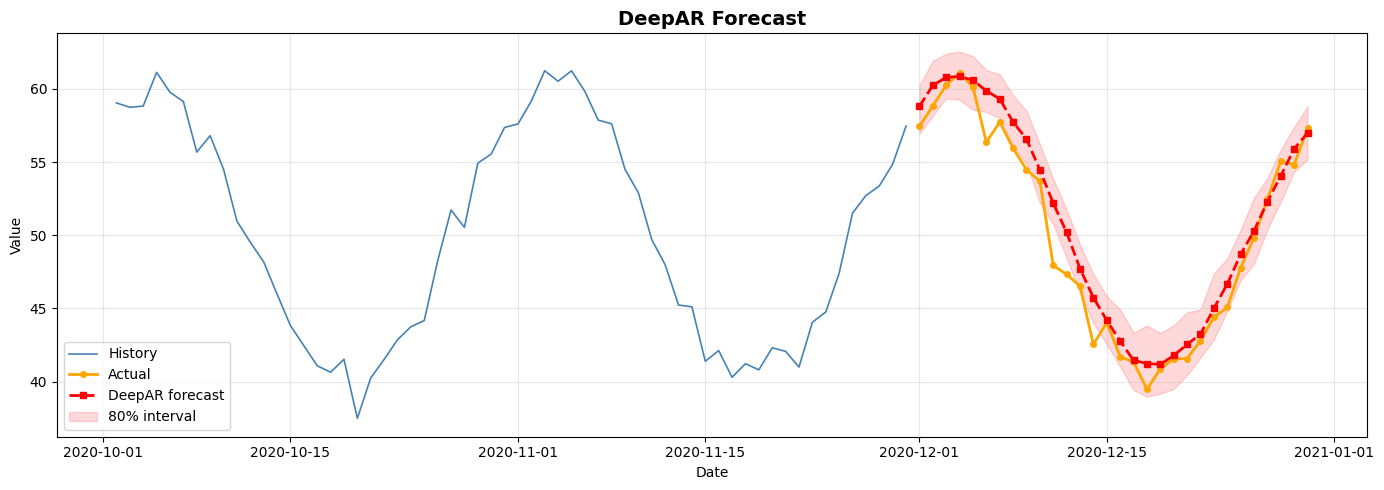

In [7]:
synth.plot_forecast_result(sin_data, deepar_forecast, model_name="DeepAR")

### Evaluate DeepAR

| Metric | What it measures |
|--------|------------------|
| **MAE** | Average absolute error (in original units) |
| **RMSE** | Like MAE but penalizes large errors more |
| **MAPE** | Percentage error — scale-independent |

In [8]:
sin_actuals = sin_data["test_df"]["value"].values
deepar_sin_metrics = calculate_metrics(deepar_forecast.mean, sin_actuals)

print("DeepAR on Sinusoid")
print("=" * 40)
print(f"  MAE:  {deepar_sin_metrics['mae']:.2f}")
print(f"  RMSE: {deepar_sin_metrics['rmse']:.2f}")
print(f"  MAPE: {deepar_sin_metrics['mape']:.2f}%")

DeepAR on Sinusoid
  MAE:  1.22
  RMSE: 1.60
  MAPE: 2.47%


> **The GluonTS pattern:** You just completed the full workflow — configure, train, forecast, visualize, evaluate. This is the same 5-step pattern for *every* GluonTS model. From here on we'll move faster since you know the drill. What changes between sections is the **data** (increasing complexity) and the **model** (different architectures), not the workflow itself.

---

# Level 2: Multi-Frequency — Adding Realism

Real time series rarely consist of a single clean cycle. This synthetic series combines:

- **Linear trend** — a slow upward drift over time
- **30-day seasonal cycle** — the dominant pattern (like monthly seasonality)
- **7-day weekly cycle** — a secondary oscillation
- **Gaussian noise** — random variation

This is much closer to what you'd see in real business or health data.

## Generate and Visualize

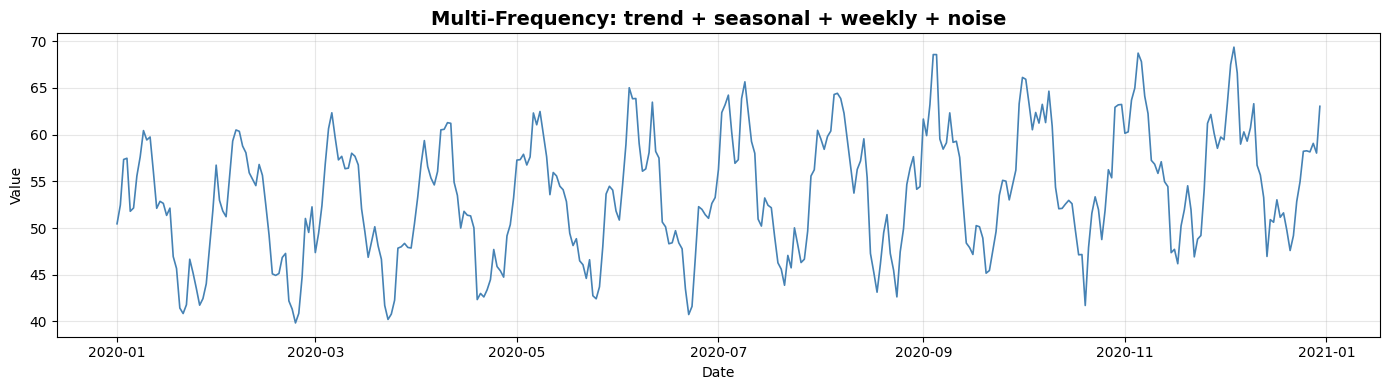

In [9]:
multi_df = synth.generate_multi_frequency(
    n_points=365,
    noise_std=1.5,
    seed=42,
)

synth.plot_synthetic_series(multi_df, title="Multi-Frequency: trend + seasonal + weekly + noise")

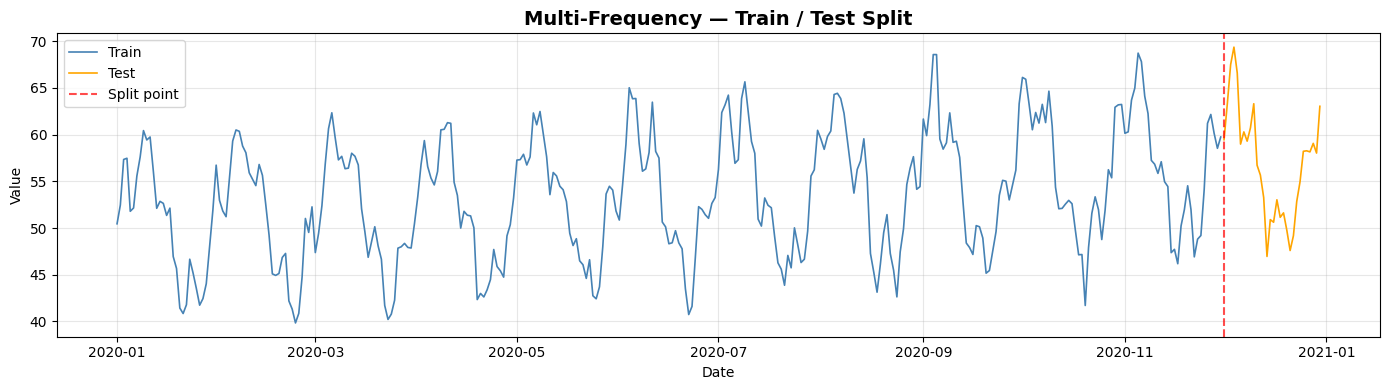

In [10]:
multi_data = synth.prepare_synthetic_dataset(
    multi_df,
    prediction_length=PREDICTION_LENGTH,
)

synth.plot_train_test_split(multi_data, title="Multi-Frequency — Train / Test Split")

## DeepAR on Multi-Frequency

We use the same DeepAR configuration. The question is: can it decompose the overlapping cycles and extrapolate the trend?

In [11]:
deepar_multi_est = DeepAREstimator(
    prediction_length=PREDICTION_LENGTH,
    context_length=60,
    freq="D",
    num_layers=2,
    hidden_size=40,
    trainer_kwargs={"max_epochs": 5},
)

deepar_multi_pred = deepar_multi_est.train(multi_data["train_ds"])
print("DeepAR training complete")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs

  | Name  | Type        | Params | In sizes                                                         | Out sizes   
------------------------------------------------------------------------------------------------------------------------
0 | model | DeepARModel | 25.9 K | [[1, 1], [1, 1], [1, 1152, 4], [1, 1152], [1, 1152], [1, 30, 4]] | [1, 100, 30]
------------------------------------------------------------------------------------------------------------------------
25.9 K    Trainable params
0         Non-trainable params
25.9 K    Total params
0.104     Total estimated model params size (MB)


Epoch 0: |                                       | 50/? [00:00<00:00, 50.20it/s, v_num=5, train_loss=4.160]

Epoch 0, global step 50: 'train_loss' reached 4.16281 (best 4.16281), saving model to '/curr_dir/lightning_logs/version_5/checkpoints/epoch=0-step=50.ckpt' as top 1


Epoch 1: |                                       | 50/? [00:00<00:00, 51.43it/s, v_num=5, train_loss=2.960]

Epoch 1, global step 100: 'train_loss' reached 2.96401 (best 2.96401), saving model to '/curr_dir/lightning_logs/version_5/checkpoints/epoch=1-step=100.ckpt' as top 1


...

Epoch 3: |                                       | 50/? [00:01<00:00, 48.27it/s, v_num=5, train_loss=2.210]

Epoch 3, global step 200: 'train_loss' reached 2.20563 (best 2.20563), saving model to '/curr_dir/lightning_logs/version_5/checkpoints/epoch=3-step=200.ckpt' as top 1


Epoch 4: |                                       | 50/? [00:00<00:00, 52.28it/s, v_num=5, train_loss=2.000]

Epoch 4, global step 250: 'train_loss' reached 2.00279 (best 2.00279), saving model to '/curr_dir/lightning_logs/version_5/checkpoints/epoch=4-step=250.ckpt' as top 1
`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4: |                                       | 50/? [00:00<00:00, 51.91it/s, v_num=5, train_loss=2.000]
DeepAR training complete


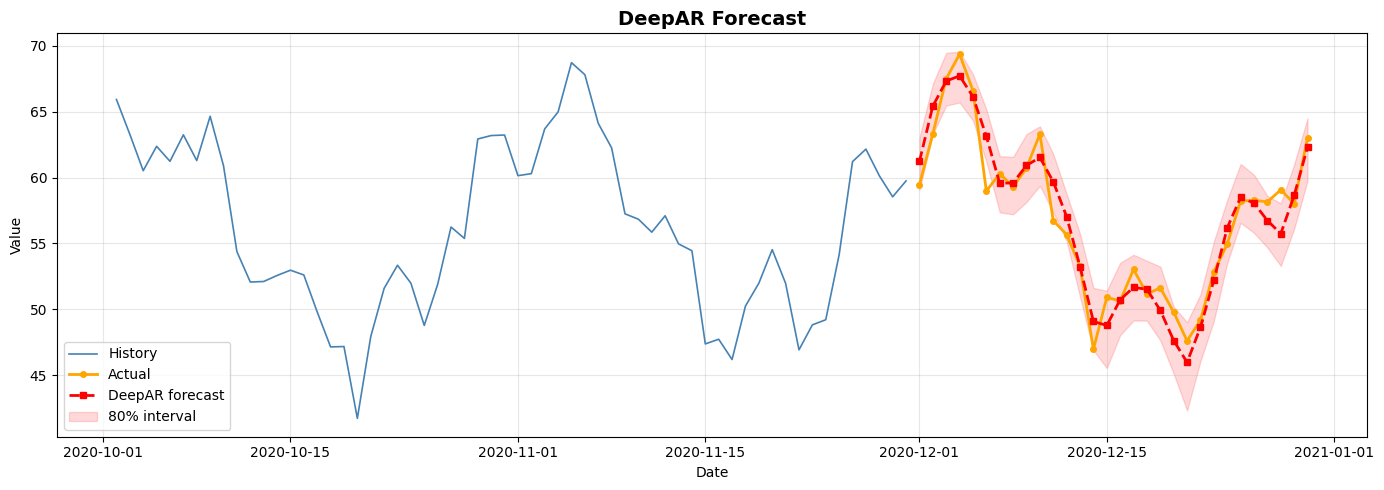

In [12]:
forecast_it, ts_it = make_evaluation_predictions(
    dataset=multi_data["test_ds"],
    predictor=deepar_multi_pred,
    num_samples=100,
)
deepar_multi_fc = list(forecast_it)[0]

synth.plot_forecast_result(multi_data, deepar_multi_fc, model_name="DeepAR")

In [13]:
multi_actuals = multi_data["test_df"]["value"].values
deepar_multi_metrics = calculate_metrics(deepar_multi_fc.mean, multi_actuals)

print("DeepAR on Multi-Frequency")
print("=" * 40)
print(f"  MAE:  {deepar_multi_metrics['mae']:.2f}")
print(f"  RMSE: {deepar_multi_metrics['rmse']:.2f}")
print(f"  MAPE: {deepar_multi_metrics['mape']:.2f}%")

DeepAR on Multi-Frequency
  MAE:  1.27
  RMSE: 1.63
  MAPE: 2.27%


## SimpleFeedForward on Multi-Frequency

**Analogy:** If DeepAR reads the whole book, SimpleFeedForward just glances at the last few pages and guesses what happens next.

It takes a fixed window of recent values and directly maps them to the forecast horizon through a feedforward neural network. No recurrence, no memory.

### Key API Differences from DeepAR

| | DeepAR | SimpleFeedForward |
|---|---|---|
| Architecture | RNN (sequential) | Feedforward (direct) |
| Hidden layers | `hidden_size` (single int) | `hidden_dimensions` (list) |
| External features | Supported (`num_feat_dynamic_real`) | Not supported |
| Speed | Slower | Much faster |

In [14]:
ff_estimator = SimpleFeedForwardEstimator(
    prediction_length=PREDICTION_LENGTH,
    context_length=60,
    hidden_dimensions=[40, 40],
    trainer_kwargs={"max_epochs": 5},
)

ff_predictor = ff_estimator.train(multi_data["train_ds"])
print("SimpleFeedForward training complete")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs

  | Name  | Type                   | Params
-------------------------------------------------
0 | model | SimpleFeedForwardModel | 51.8 K
-------------------------------------------------
51.8 K    Trainable params
0         Non-trainable params
51.8 K    Total params
0.207     Total estimated model params size (MB)


Epoch 0: |                                      | 50/? [00:00<00:00, 281.07it/s, v_num=6, train_loss=4.850]

Epoch 0, global step 50: 'train_loss' reached 4.84688 (best 4.84688), saving model to '/curr_dir/lightning_logs/version_6/checkpoints/epoch=0-step=50.ckpt' as top 1


Epoch 1: |                                      | 50/? [00:00<00:00, 265.14it/s, v_num=6, train_loss=3.380]

Epoch 1, global step 100: 'train_loss' reached 3.37749 (best 3.37749), saving model to '/curr_dir/lightning_logs/version_6/checkpoints/epoch=1-step=100.ckpt' as top 1


...

Epoch 3: |                                      | 50/? [00:00<00:00, 366.94it/s, v_num=6, train_loss=2.830]

Epoch 3, global step 200: 'train_loss' reached 2.82643 (best 2.82643), saving model to '/curr_dir/lightning_logs/version_6/checkpoints/epoch=3-step=200.ckpt' as top 1


Epoch 4: |                                      | 50/? [00:00<00:00, 344.34it/s, v_num=6, train_loss=2.660]

Epoch 4, global step 250: 'train_loss' reached 2.65813 (best 2.65813), saving model to '/curr_dir/lightning_logs/version_6/checkpoints/epoch=4-step=250.ckpt' as top 1
`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4: |                                      | 50/? [00:00<00:00, 330.77it/s, v_num=6, train_loss=2.660]
SimpleFeedForward training complete


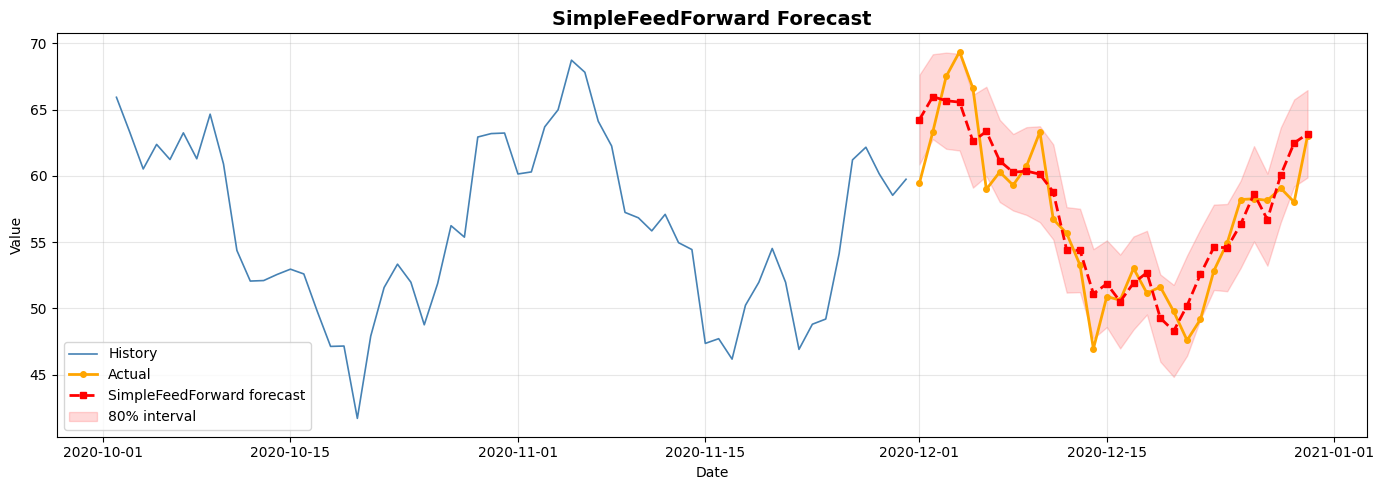

In [15]:
forecast_it, ts_it = make_evaluation_predictions(
    dataset=multi_data["test_ds"],
    predictor=ff_predictor,
    num_samples=100,
)
ff_multi_fc = list(forecast_it)[0]

synth.plot_forecast_result(multi_data, ff_multi_fc, model_name="SimpleFeedForward")

In [16]:
ff_multi_metrics = calculate_metrics(ff_multi_fc.mean, multi_actuals)

print("SimpleFeedForward on Multi-Frequency")
print("=" * 40)
print(f"  MAE:  {ff_multi_metrics['mae']:.2f}")
print(f"  RMSE: {ff_multi_metrics['rmse']:.2f}")
print(f"  MAPE: {ff_multi_metrics['mape']:.2f}%")

SimpleFeedForward on Multi-Frequency
  MAE:  2.01
  RMSE: 2.45
  MAPE: 3.55%


---

# Level 3: Regime Change — The Hard Problem

This is where things get interesting. The series behaves one way for the first half, then **abruptly shifts** to a different baseline, amplitude, and frequency.

Think of real-world analogs:
- A new COVID variant causing a sudden surge
- A product going viral and changing demand patterns
- A policy change shifting economic indicators

Most models struggle here because their training data comes from the old regime, but they need to forecast in the new one.

## Generate and Visualize

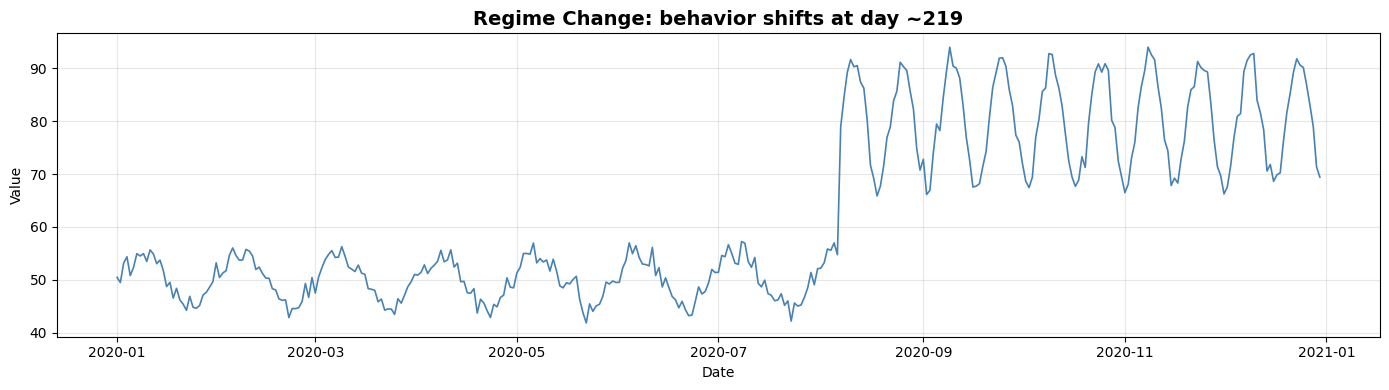

In [17]:
regime_df = synth.generate_regime_change(
    n_points=365,
    changepoint_frac=0.6,
    noise_std=1.5,
    seed=42,
)

synth.plot_synthetic_series(regime_df, title="Regime Change: behavior shifts at day ~219")

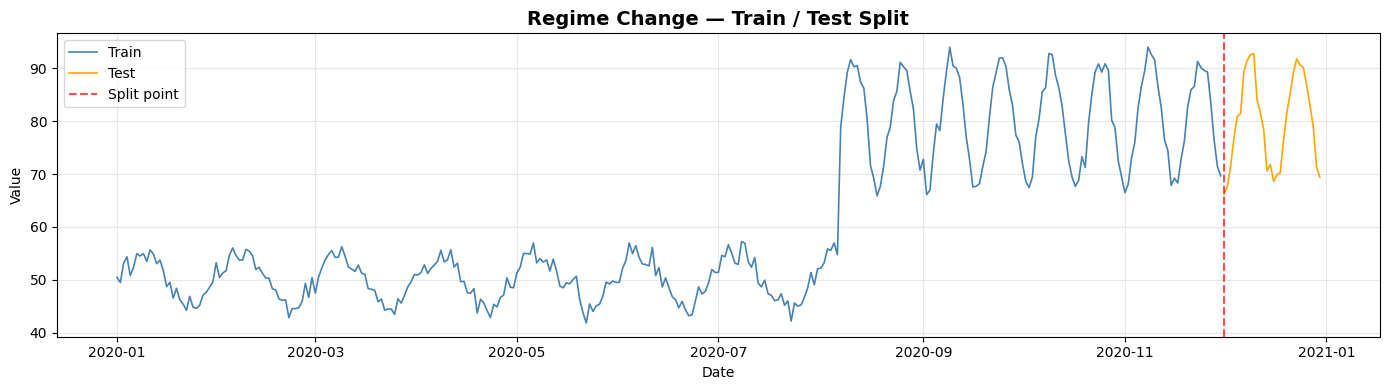

In [18]:
regime_data = synth.prepare_synthetic_dataset(
    regime_df,
    prediction_length=PREDICTION_LENGTH,
)

synth.plot_train_test_split(regime_data, title="Regime Change — Train / Test Split")

## DeepNPTS on Regime Change

**Analogy:** DeepAR and SimpleFeedForward assume the future follows a *known* distribution shape (Gaussian). DeepNPTS makes **no such assumption** — it learns the distribution directly from the data.

This makes it better suited for data where the underlying process changes.

### Key API Differences

| | DeepAR | DeepNPTS |
|---|---|---|
| Distribution | Parametric (Gaussian) | Non-parametric (learned) |
| Epochs config | `trainer_kwargs={"max_epochs": N}` | `epochs=N` (direct parameter) |
| Hidden layers | `hidden_size` (single int) | `num_hidden_nodes` (list) |
| Regime shifts | Can struggle | Designed for this |

In [19]:
npts_estimator = DeepNPTSEstimator(
    prediction_length=PREDICTION_LENGTH,
    context_length=60,
    freq="D",
    num_hidden_nodes=[40, 40],
    epochs=5,
)

npts_predictor = npts_estimator.train(regime_data["train_ds"])
print("DeepNPTS training complete")

Loss for epoch 0: 2.3770784509181975
Loss for epoch 1: 2.220843241214752
Loss for epoch 2: 2.14502729177475
Loss for epoch 3: 1.9193781596422195
Loss for epoch 4: 1.8354431653022767
Best loss: 1.8354431653022767
DeepNPTS training complete


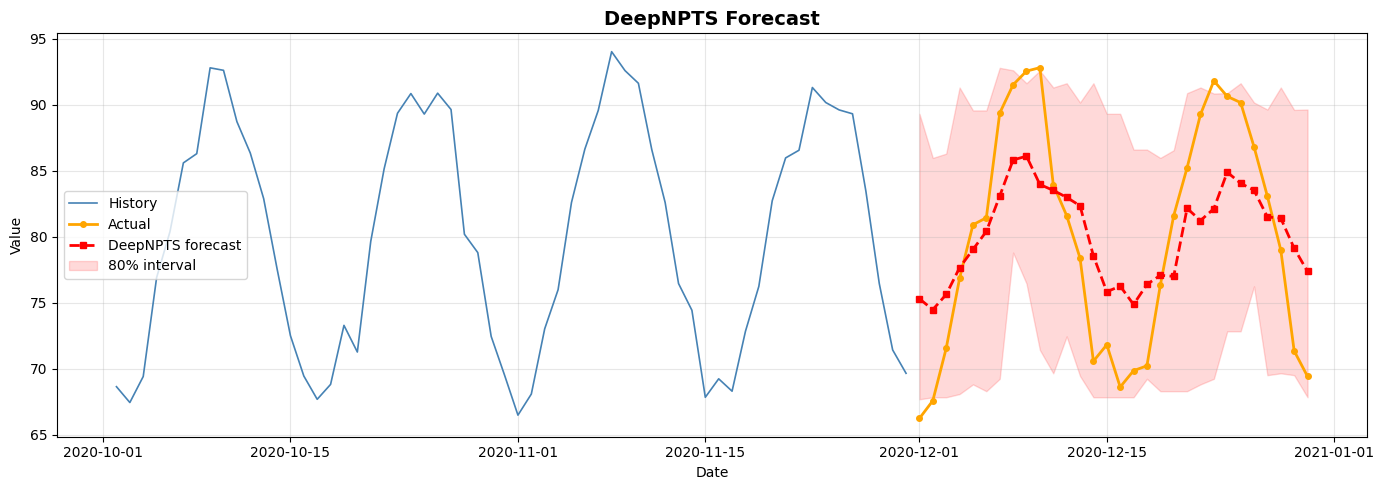

In [20]:
forecast_it, ts_it = make_evaluation_predictions(
    dataset=regime_data["test_ds"],
    predictor=npts_predictor,
    num_samples=100,
)
npts_regime_fc = list(forecast_it)[0]

synth.plot_forecast_result(regime_data, npts_regime_fc, model_name="DeepNPTS")

In [21]:
regime_actuals = regime_data["test_df"]["value"].values
npts_regime_metrics = calculate_metrics(npts_regime_fc.mean, regime_actuals)

print("DeepNPTS on Regime Change")
print("=" * 40)
print(f"  MAE:  {npts_regime_metrics['mae']:.2f}")
print(f"  RMSE: {npts_regime_metrics['rmse']:.2f}")
print(f"  MAPE: {npts_regime_metrics['mape']:.2f}%")

DeepNPTS on Regime Change
  MAE:  4.95
  RMSE: 5.67
  MAPE: 6.31%


## DeepAR on Regime Change (Contrast)

Let's run DeepAR on the same regime-change data to see how it compares. Because DeepAR assumes a parametric distribution learned from the full training set, it may struggle with the post-shift behavior.

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs

  | Name  | Type        | Params | In sizes                                                         | Out sizes   
------------------------------------------------------------------------------------------------------------------------
0 | model | DeepARModel | 25.9 K | [[1, 1], [1, 1], [1, 1152, 4], [1, 1152], [1, 1152], [1, 30, 4]] | [1, 100, 30]
------------------------------------------------------------------------------------------------------------------------
25.9 K    Trainable params
0         Non-trainable params
25.9 K    Total params
0.104     Total estimated model params size (MB)


Epoch 0: |                                       | 50/? [00:01<00:00, 49.07it/s, v_num=7, train_loss=4.040]

Epoch 0, global step 50: 'train_loss' reached 4.04478 (best 4.04478), saving model to '/curr_dir/lightning_logs/version_7/checkpoints/epoch=0-step=50.ckpt' as top 1


Epoch 1: |                                       | 50/? [00:01<00:00, 48.59it/s, v_num=7, train_loss=3.180]

Epoch 1, global step 100: 'train_loss' reached 3.17951 (best 3.17951), saving model to '/curr_dir/lightning_logs/version_7/checkpoints/epoch=1-step=100.ckpt' as top 1


...

Epoch 3: |                                       | 50/? [00:01<00:00, 35.49it/s, v_num=7, train_loss=2.680]

Epoch 3, global step 200: 'train_loss' reached 2.68208 (best 2.68208), saving model to '/curr_dir/lightning_logs/version_7/checkpoints/epoch=3-step=200.ckpt' as top 1


Epoch 4: |                                       | 50/? [00:01<00:00, 48.59it/s, v_num=7, train_loss=2.770]

Epoch 4, global step 250: 'train_loss' was not in top 1
`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4: |                                       | 50/? [00:01<00:00, 48.37it/s, v_num=7, train_loss=2.770]


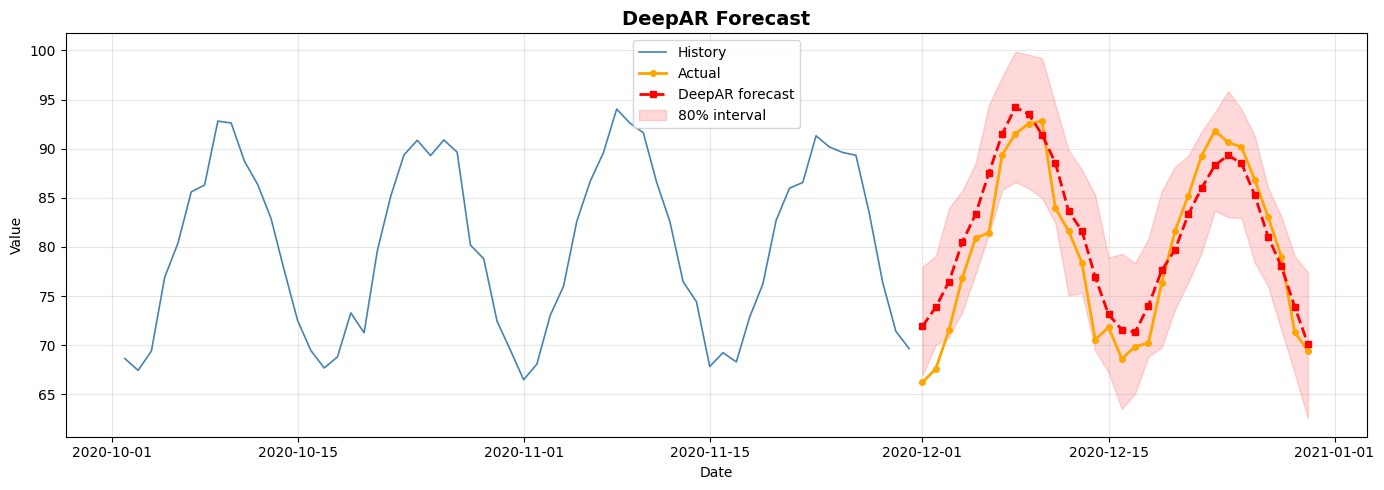

In [22]:
deepar_regime_est = DeepAREstimator(
    prediction_length=PREDICTION_LENGTH,
    context_length=60,
    freq="D",
    num_layers=2,
    hidden_size=40,
    trainer_kwargs={"max_epochs": 5},
)

deepar_regime_pred = deepar_regime_est.train(regime_data["train_ds"])

forecast_it, ts_it = make_evaluation_predictions(
    dataset=regime_data["test_ds"],
    predictor=deepar_regime_pred,
    num_samples=100,
)
deepar_regime_fc = list(forecast_it)[0]

synth.plot_forecast_result(regime_data, deepar_regime_fc, model_name="DeepAR")

In [23]:
deepar_regime_metrics = calculate_metrics(deepar_regime_fc.mean, regime_actuals)

print("DeepAR on Regime Change")
print("=" * 40)
print(f"  MAE:  {deepar_regime_metrics['mae']:.2f}")
print(f"  RMSE: {deepar_regime_metrics['rmse']:.2f}")
print(f"  MAPE: {deepar_regime_metrics['mape']:.2f}%")

DeepAR on Regime Change
  MAE:  2.82
  RMSE: 3.27
  MAPE: 3.65%


---

# Model Comparison

Let's bring all results together. Each model was tested on the data type that best highlights its strengths and weaknesses.

In [24]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "DeepAR (sinusoid)",
        "DeepAR (multi-freq)",
        "SimpleFeedForward (multi-freq)",
        "DeepNPTS (regime change)",
        "DeepAR (regime change)",
    ],
    "MAE": [
        deepar_sin_metrics["mae"],
        deepar_multi_metrics["mae"],
        ff_multi_metrics["mae"],
        npts_regime_metrics["mae"],
        deepar_regime_metrics["mae"],
    ],
    "RMSE": [
        deepar_sin_metrics["rmse"],
        deepar_multi_metrics["rmse"],
        ff_multi_metrics["rmse"],
        npts_regime_metrics["rmse"],
        deepar_regime_metrics["rmse"],
    ],
    "MAPE (%)": [
        deepar_sin_metrics["mape"],
        deepar_multi_metrics["mape"],
        ff_multi_metrics["mape"],
        npts_regime_metrics["mape"],
        deepar_regime_metrics["mape"],
    ],
})

print(comparison.to_string(index=False, float_format="%.2f"))

                         Model  MAE  RMSE  MAPE (%)
             DeepAR (sinusoid) 1.22  1.60      2.47
           DeepAR (multi-freq) 1.27  1.63      2.27
SimpleFeedForward (multi-freq) 2.01  2.45      3.55
      DeepNPTS (regime change) 4.95  5.67      6.31
        DeepAR (regime change) 2.82  3.27      3.65


## Which Model Should You Choose?

| Scenario | Recommended model | Why |
|----------|-------------------|-----|
| Clean periodic data, complex seasonality | **DeepAR** | RNN captures long-range dependencies and layered patterns |
| Stable trends, need a quick baseline | **SimpleFeedForward** | Fast to train, works well when patterns are simple |
| Data changes behavior over time | **DeepNPTS** | Non-parametric — doesn't assume one distribution fits the whole series |
| Not sure yet | **Start with DeepAR** | Best general-purpose choice, then compare |

**Key takeaway:** There is no single "best" model. The right choice depends on your data's characteristics. The synthetic experiments above give you intuition for *why* each model succeeds or struggles.

---

# Summary

## What You Learned

In this tutorial you went from synthetic time series to evaluated probabilistic forecasts. Here's the GluonTS workflow you now know:

```
1. Prepare data     →  DataFrame with Date + target columns
2. Create dataset   →  ListDataset(entries, freq="D")
3. Configure model  →  DeepAREstimator(...) / SimpleFeedForwardEstimator(...) / DeepNPTSEstimator(...)
4. Train            →  predictor = estimator.train(train_ds)
5. Forecast         →  make_evaluation_predictions(test_ds, predictor)
6. Evaluate         →  calculate_metrics(forecast.mean, actuals)
```

## Cheat Sheet

| Task | Code |
|------|------|
| Get forecast mean | `forecast.mean` |
| Get 90th percentile | `forecast.quantile(0.9)` |
| Get raw sample paths | `forecast.samples` |
| Median forecast | `forecast.quantile(0.5)` |

## What's Next?

Now that you understand how GluonTS works on clean data, move to **`GluonTS.example.ipynb`** to see these same models applied to real **COVID-19 case prediction** — with feature engineering, multiple covariates, scenario analysis, and all the messiness of real-world data.